# Economic and statistical USD/ZAR models with backward selection

This notebook extends `boosting_test.ipynb` while preserving its core strategy: at every round, remove the feature whose removal gives the lowest mean expanding-window CV RMSE; follow the complete path through the zero-feature benchmark; and retain the best subset encountered anywhere on that path.

The target is the 28-day level movement, `usd_zar_28 - usd_zar`. The model families test complementary assumptions:

- **OLS**: an interpretable linear economic baseline.
- **Ridge**: stabilises correlated macro/market predictors with L2 shrinkage.
- **Elastic Net**: combines sparse L1 selection with L2 shrinkage.
- **Huber**: a robust linear model that reduces the influence of crisis outliers.
- **Spline Ridge**: permits smooth nonlinear effects while remaining regularised.

Economic channels include interest-rate carry, sovereign yield spreads, commodity-currency exposure, global dollar/risk conditions, domestic credit risk, inflation, and FX momentum/volatility. All transformations are backward-looking. Scaling and spline fitting live inside sklearn pipelines, so they are re-estimated on each training fold and do not leak test-fold information.

## References and modelling rationale

- sklearn's [linear-model guide](https://scikit-learn.org/stable/modules/linear_model.html) defines OLS, Ridge, Elastic Net and Huber objectives. It notes that Ridge improves stability under collinearity, Elastic Net is useful with correlated predictors, and Huber limits outlier influence.
- sklearn's [TimeSeriesSplit documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) describes expanding training windows where later folds follow earlier folds.
- sklearn's [SplineTransformer documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html) provides the B-spline basis used for the nonlinear specification.

These are predictive comparisons, not causal estimates. Feature selection is nested within the same CV used to compare subsets, so its RMSE is a model-selection score rather than an unbiased final performance estimate. The last section therefore includes a strict chronological holdout rerun.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from joblib import Parallel, delayed, parallel_config
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, HuberRegressor, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
N_SPLITS = 5
N_JOBS = 4
sns.set_theme(style="whitegrid")

In [2]:
data = (
    pd.read_parquet("../data/train.parquet")
    .sort_values("date")
    .reset_index(drop=True)
)

y = (data["usd_zar_28"] - data["usd_zar"]).rename("usd_zar_28_movement")
print(f"{len(data):,} rows from {data.date.min():%Y-%m-%d} to {data.date.max():%Y-%m-%d}")
display(y.describe().to_frame().T)

3,190 rows from 2008-10-10 to 2020-12-31


,count,mean,std,min,25%,50%,75%,max
usd_zar_28_movement,3190.0,0.031114,0.5236,-1.9434,-0.2649,0.0059,0.3058,3.1222


## Economic feature engineering

Differences and ratios encode economic channels more directly than including only both legs separately. Log changes make price-series movements more comparable across units. Rolling statistics use `.shift(1)`, so the rolling window ends before the row being predicted. `usd_zar_28` is never a predictor.

In [3]:
X = data.drop(columns=["date", "usd_zar_28"]).copy()

# Carry, rates and domestic risk channels.
X["policy_rate_differential"] = X["sa_repo_rate"] - X["us_fed_funds"]
X["five_year_yield_spread"] = X["sa_5y_yield"] - X["us_5y_yield"]
X["sa_real_rate_proxy"] = X["sa_repo_rate"] - X["sa_yoy_inflation"]
X["risk_adjusted_carry"] = X["policy_rate_differential"] / (1.0 + X["sa_5y_cds_bp"] / 100.0)
X["global_risk_interaction"] = np.log1p(X["vix"]) * np.log1p(X["sa_5y_cds_bp"])

# Commodity-currency and global-dollar channels.
commodity_columns = [
    "gold_usd_per_oz", "platinum_usd_per_oz",
    "iron_ore_usd_per_tonne", "richards_bay_coal_usd",
]
log_commodities = np.log(X[commodity_columns])
# Normalise to the first historically available row (a fixed, past-only base).
X["commodity_price_factor"] = log_commodities.sub(log_commodities.iloc[0]).mean(axis=1)
X["precious_metals_return"] = X[["gold_usd_per_oz_return", "platinum_usd_per_oz_return"]].mean(axis=1)
X["terms_of_trade_proxy"] = X["commodity_price_factor"] - np.log(X["brent_usd_per_barrel"])

# Backward-looking FX dynamics. Shift prevents the rolling window using today's value.
log_spot = np.log(X["usd_zar"])
daily_fx_return = log_spot.diff()
for window in (5, 21, 63):
    X[f"fx_log_return_{window}d"] = log_spot.diff(window)
    X[f"fx_realized_vol_{window}d"] = daily_fx_return.shift(1).rolling(window).std()

# Growth/inflation changes use only current and earlier published observations.
X["sa_cpi_log_change_21d"] = np.log(X["sa_cpi"]).diff(21)
X["sa_real_gdp_log_change_63d"] = np.log(X["sa_real_gdp"]).diff(63)

# Remove warm-up rows jointly from X and y.
valid = X.notna().all(axis=1) & y.notna()
X, y, dates = X.loc[valid].reset_index(drop=True), y.loc[valid].reset_index(drop=True), data.loc[valid, "date"].reset_index(drop=True)

assert "usd_zar_28" not in X.columns
assert X.select_dtypes(exclude="number").empty
print(f"Model matrix: {X.shape[0]:,} rows x {X.shape[1]} features")

Model matrix: 3,126 rows x 38 features


## Full-path backward stepwise selection

This is the same greedy complete-path rule used in `boosting_test`: evaluate every one-feature removal, accept the best removal even if RMSE worsens, and return the best subset seen over the whole path. The empty subset is scored by a training-fold mean. Candidate evaluations are parallelised; estimator-level parallelism should remain at one to avoid oversubscription.

In [4]:
def _progress(message):
    print(f"{time.strftime('%H:%M:%S')} | {message}", flush=True)


def backward_stepwise_selection(estimator, X, y, n_splits=5, n_jobs=4, log_every=None):
    """Return the best subset and the exhaustive greedy elimination history."""
    selected_features = list(X.columns)
    splits = list(TimeSeriesSplit(n_splits=n_splits).split(X))
    total_start = time.perf_counter()
    n_jobs = max(1, min(n_jobs, len(selected_features)))
    base_estimator = clone(estimator)

    def cv_rmse(features, verbose=False):
        fold_rmses = []
        for fold, (train_idx, test_idx) in enumerate(splits, start=1):
            if features:
                fold_model = clone(base_estimator)
                fold_model.fit(X.iloc[train_idx][features], y.iloc[train_idx])
                predictions = np.asarray(fold_model.predict(X.iloc[test_idx][features])).ravel()
            else:
                predictions = np.full(len(test_idx), y.iloc[train_idx].mean())
            score = root_mean_squared_error(y.iloc[test_idx], predictions)
            fold_rmses.append(score)
            if verbose:
                _progress(f"Baseline fold {fold}/{len(splits)} complete; RMSE={score:.6f}")
        return float(np.mean(fold_rmses))

    def evaluate_candidate(feature, remaining):
        return cv_rmse(remaining), feature

    _progress(f"Starting with {len(selected_features)} features, {n_splits} folds, {n_jobs} workers")
    current_rmse = cv_rmse(selected_features, verbose=True)
    best_rmse, best_features = current_rmse, selected_features.copy()
    history = [{
        "step": 0, "removed": None, "n_features": len(selected_features),
        "remaining_features": tuple(selected_features), "cv_rmse": current_rmse,
        "change_from_previous": np.nan, "best_so_far": True,
        "round_seconds": 0.0, "elapsed_seconds": time.perf_counter() - total_start,
    }]

    step = 0
    while selected_features:
        step += 1
        round_start = time.perf_counter()
        candidates = [
            (feature, [name for name in selected_features if name != feature])
            for feature in selected_features
        ]
        report_every = log_every or max(1, len(candidates) // 5)
        completed_results = []
        with parallel_config(backend="loky", n_jobs=n_jobs, inner_max_num_threads=1):
            generator = Parallel(return_as="generator_unordered")(
                delayed(evaluate_candidate)(feature, remaining)
                for feature, remaining in candidates
            )
            for completed, result in enumerate(generator, start=1):
                completed_results.append(result)
                if completed % report_every == 0 or completed == len(candidates):
                    _progress(f"Round {step}: {completed}/{len(candidates)} candidates complete")

        candidate_rmse, feature_to_remove = min(completed_results)
        previous_rmse = current_rmse
        selected_features.remove(feature_to_remove)
        current_rmse = candidate_rmse
        is_best = current_rmse < best_rmse
        if is_best:
            best_rmse, best_features = current_rmse, selected_features.copy()
        history.append({
            "step": step, "removed": feature_to_remove,
            "n_features": len(selected_features),
            "remaining_features": tuple(selected_features), "cv_rmse": current_rmse,
            "change_from_previous": current_rmse - previous_rmse,
            "best_so_far": is_best,
            "round_seconds": time.perf_counter() - round_start,
            "elapsed_seconds": time.perf_counter() - total_start,
        })
        _progress(f"Round {step}: removed '{feature_to_remove}'; RMSE={current_rmse:.6f}")

    _progress(f"Finished; best subset has {len(best_features)} features, RMSE={best_rmse:.6f}")
    return best_features, pd.DataFrame(history)

## Estimator specifications

Hyperparameters are deliberately fixed before subset search. Tuning them on these same folds would add another layer of selection optimism. Standardisation is fold-local. `TransformedTargetRegressor` standardises the target for Elastic Net and Huber, then maps forecasts back to USD/ZAR movement units.

In [5]:
scaled_ols = make_pipeline(StandardScaler(), LinearRegression())
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
elastic_net = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        ElasticNet(alpha=0.02, l1_ratio=0.35, max_iter=20_000, random_state=RANDOM_STATE),
    ),
    transformer=StandardScaler(),
)
huber = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        HuberRegressor(epsilon=1.35, alpha=0.01, max_iter=2_000),
    ),
    transformer=StandardScaler(),
)
spline_ridge = make_pipeline(
    StandardScaler(),
    SplineTransformer(n_knots=4, degree=2, include_bias=False),
    Ridge(alpha=25.0),
)

models = {
    "OLS": scaled_ols,
    "Ridge": ridge,
    "Elastic Net": elastic_net,
    "Huber": huber,
    "Spline Ridge": spline_ridge,
}
models

{'OLS': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('linearregression', LinearRegression())]),
 'Ridge': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('ridge', Ridge(alpha=10.0))]),
 'Elastic Net': TransformedTargetRegressor(regressor=Pipeline(steps=[('standardscaler',
                                                       StandardScaler()),
                                                      ('elasticnet',
                                                       ElasticNet(alpha=0.02,
                                                                  l1_ratio=0.35,
                                                                  max_iter=20000,
                                                                  random_state=42))]),
                            transformer=StandardScaler()),
 'Huber': TransformedTargetRegressor(regressor=Pipeline(steps=[('standardscaler',
                                                       StandardS

## Run every model through the same elimination path

This is computationally intensive: with *p* features, each estimator fits `n_splits × p(p+1)/2` non-empty candidate models plus its baseline. Set `MODELS_TO_RUN` to a subset while iterating; the default runs all specifications.

In [6]:
MODELS_TO_RUN = list(models)  # e.g. ["OLS", "Ridge"] for a quick pass

selection_results = {}
summary_rows = []

for model_name in MODELS_TO_RUN:
    print(f"\n{'=' * 20} {model_name} {'=' * 20}", flush=True)
    best_features, history = backward_stepwise_selection(
        models[model_name], X, y, n_splits=N_SPLITS, n_jobs=N_JOBS
    )
    best_row = history.loc[history["cv_rmse"].idxmin()]
    selection_results[model_name] = {
        "estimator": models[model_name],
        "best_features": best_features,
        "history": history,
    }
    summary_rows.append({
        "model": model_name,
        "cv_rmse": best_row["cv_rmse"],
        "n_features": len(best_features),
        "features": tuple(best_features),
    })

model_summary = pd.DataFrame(summary_rows).sort_values("cv_rmse").reset_index(drop=True)
display(model_summary)


==================== OLS ====================
17:51:55 | Starting with 38 features, 5 folds, 4 workers
17:51:55 | Baseline fold 1/5 complete; RMSE=2.590548
17:51:55 | Baseline fold 2/5 complete; RMSE=1.611648
17:51:55 | Baseline fold 3/5 complete; RMSE=1.566430
17:51:55 | Baseline fold 4/5 complete; RMSE=0.790342
17:51:56 | Baseline fold 5/5 complete; RMSE=1.259087
17:51:59 | Round 1: 7/38 candidates complete
17:51:59 | Round 1: 14/38 candidates complete
17:51:59 | Round 1: 21/38 candidates complete
17:52:00 | Round 1: 28/38 candidates complete
17:52:00 | Round 1: 35/38 candidates complete
17:52:00 | Round 1: 38/38 candidates complete
17:52:00 | Round 1: removed 'usd_zar'; RMSE=1.320146
17:52:00 | Round 2: 7/37 candidates complete
17:52:00 | Round 2: 14/37 candidates complete
17:52:01 | Round 2: 21/37 candidates complete
17:52:01 | Round 2: 28/37 candidates complete
17:52:01 | Round 2: 35/37 candidates complete
17:52:01 | Round 2: 37/37 candidates complete
17:52:01 | Round 2: removed 

,model,cv_rmse,n_features,features
0,Spline Ridge,0.499896,5,"(sa_repo_rate, sa_yoy_inflation, sa_real_rate_..."
1,Ridge,0.504933,3,"(sa_real_gdp, fx_log_return_5d, fx_realized_vo..."
2,Elastic Net,0.506330,6,"(sa_real_gdp, sa_5y_cds_bp, sa_5y_yield, polic..."
3,OLS,0.508451,1,"(fx_realized_vol_63d,)"
4,Huber,0.509304,2,"(sa_real_gdp, fx_realized_vol_21d)"


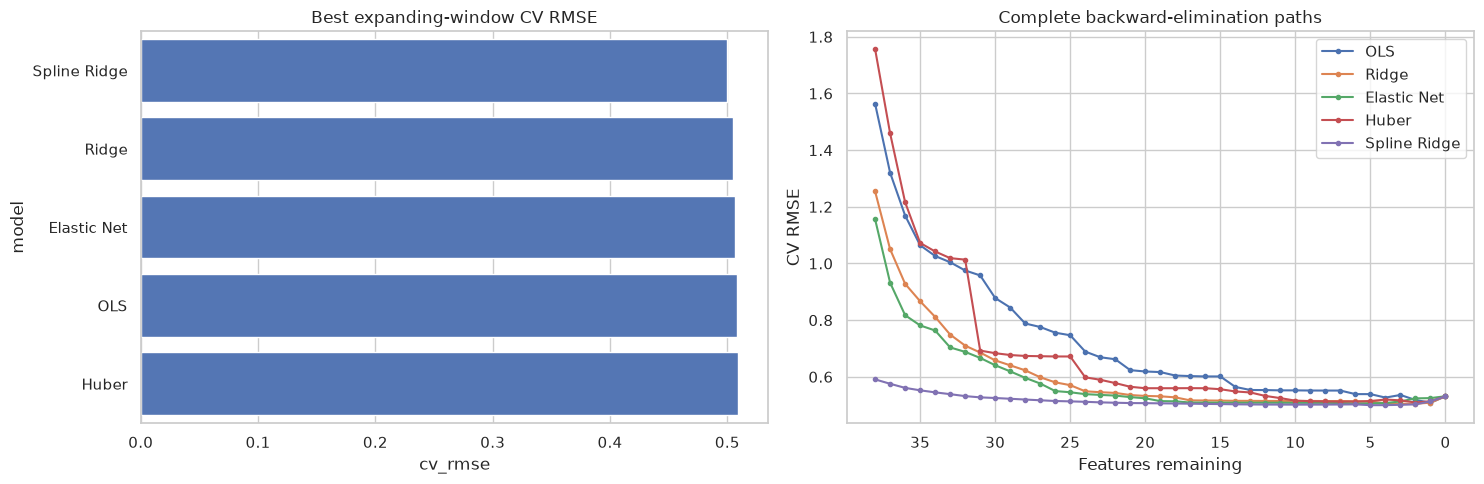

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=model_summary, x="cv_rmse", y="model", ax=axes[0], color="#4472C4")
axes[0].set_title("Best expanding-window CV RMSE")

for model_name, result in selection_results.items():
    history = result["history"]
    axes[1].plot(history["n_features"], history["cv_rmse"], marker="o", ms=3, label=model_name)
axes[1].invert_xaxis()
axes[1].set(title="Complete backward-elimination paths", xlabel="Features remaining", ylabel="CV RMSE")
axes[1].legend()
plt.tight_layout()
plt.show()

## Strict chronological holdout comparison

To reduce selection bias, the final 20% is never used during feature selection. The elimination path is rerun on the first 80%, then the selected model is fitted once on that development window and evaluated once on the holdout. This is the result to prefer when comparing model families.

In [8]:
cutoff = int(len(X) * 0.80)
X_dev, X_holdout = X.iloc[:cutoff], X.iloc[cutoff:]
y_dev, y_holdout = y.iloc[:cutoff], y.iloc[cutoff:]

holdout_rows = []
holdout_selections = {}

for model_name in MODELS_TO_RUN:
    print(f"\nHoldout workflow: {model_name}", flush=True)
    features, history = backward_stepwise_selection(
        models[model_name], X_dev, y_dev, n_splits=N_SPLITS, n_jobs=N_JOBS
    )
    if features:
        fitted = clone(models[model_name]).fit(X_dev[features], y_dev)
        prediction = np.asarray(fitted.predict(X_holdout[features])).ravel()
    else:
        fitted = DummyRegressor(strategy="mean").fit(np.ones((len(y_dev), 1)), y_dev)
        prediction = fitted.predict(np.ones((len(y_holdout), 1)))
    holdout_selections[model_name] = {"features": features, "history": history, "model": fitted}
    holdout_rows.append({
        "model": model_name,
        "holdout_rmse": root_mean_squared_error(y_holdout, prediction),
        "n_features": len(features),
        "holdout_start": dates.iloc[cutoff],
        "holdout_end": dates.iloc[-1],
        "features": tuple(features),
    })

holdout_summary = pd.DataFrame(holdout_rows).sort_values("holdout_rmse").reset_index(drop=True)
display(holdout_summary)


Holdout workflow: OLS
17:55:54 | Starting with 38 features, 5 folds, 4 workers
17:55:54 | Baseline fold 1/5 complete; RMSE=1.133836
17:55:54 | Baseline fold 2/5 complete; RMSE=1.535415
17:55:54 | Baseline fold 3/5 complete; RMSE=0.712211
17:55:54 | Baseline fold 4/5 complete; RMSE=1.047505
17:55:54 | Baseline fold 5/5 complete; RMSE=0.665120
17:55:54 | Round 1: 7/38 candidates complete
17:55:54 | Round 1: 14/38 candidates complete
17:55:54 | Round 1: 21/38 candidates complete
17:55:54 | Round 1: 28/38 candidates complete
17:55:54 | Round 1: 35/38 candidates complete
17:55:54 | Round 1: 38/38 candidates complete
17:55:54 | Round 1: removed 'platinum_usd_per_oz'; RMSE=0.925804
17:55:55 | Round 2: 7/37 candidates complete
17:55:55 | Round 2: 14/37 candidates complete
17:55:55 | Round 2: 21/37 candidates complete
17:55:55 | Round 2: 28/37 candidates complete
17:55:55 | Round 2: 35/37 candidates complete
17:55:55 | Round 2: 37/37 candidates complete
17:55:55 | Round 2: removed 'sa_real_gdp

,model,holdout_rmse,n_features,holdout_start,holdout_end,features
0,Spline Ridge,0.747323,9,2018-08-09,2020-12-31,"(iron_ore_usd_per_tonne, sa_repo_rate, sa_cpi,..."
1,Elastic Net,0.748549,6,2018-08-09,2020-12-31,"(sa_real_gdp, sa_5y_cds_bp, sa_5y_yield, polic..."
2,Ridge,0.797669,5,2018-08-09,2020-12-31,"(sa_repo_rate, sa_real_gdp, policy_rate_differ..."
3,OLS,0.806080,8,2018-08-09,2020-12-31,"(broad_usd_index, brent_usd_per_barrel, sa_cpi..."
4,Huber,0.828413,3,2018-08-09,2020-12-31,"(sa_repo_rate, usd_zar_1m_return, sa_cpi_log_c..."


## Interpretation checklist

1. Rank model families primarily by untouched holdout RMSE, not their feature-selection CV score.
2. Inspect whether selected variables form a coherent channel (carry, commodities, risk, dollar, or momentum) and whether that channel remains stable across models.
3. Treat coefficient signs as conditional associations, not structural causal effects.
4. Compare every model with the zero-feature mean row on its path. If the mean wins, the predictors did not add reliable forecasting value under this design.
5. Before production use, add a gap/embargo matching the exact 28-day label horizon if adjacent labels overlap, and confirm that every macro series reflects its historical release date rather than a revised value.